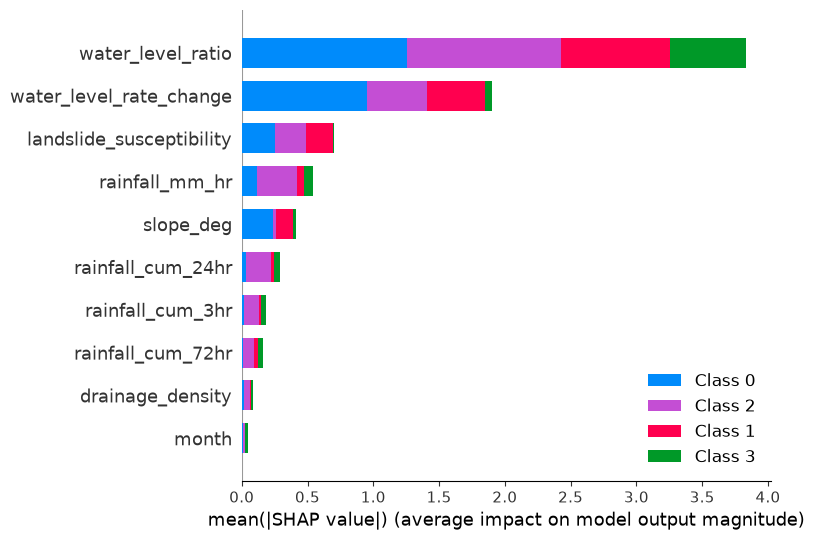

In [5]:
import pandas as pd
import joblib
import shap

# Reload everything needed, in case kernel was restarted
df = pd.read_csv('flood_final_dataset.csv')
df = df.drop(columns=["lat","lon","timestamp","state"])

susceptibility_order = {"Low": 0, "Moderate": 1, "High": 2}
df["landslide_susceptibility"] = df["landslide_susceptibility"].map(susceptibility_order)

risk_order = {"Low": 0, "Medium": 1, "High": 2, "Severe": 3}
df["label_flood_risk"] = df["label_flood_risk"].map(risk_order)

X = df.drop(columns=["label_flood_risk", "region", "water_level_m", "danger_level_m"])
y = df["label_flood_risk"]

final_model = joblib.load("flood_model.pkl")

# Now the SHAP code
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type="bar")

In [4]:
print(X.columns.tolist())

['month', 'rainfall_mm_hr', 'rainfall_cum_3hr', 'rainfall_cum_24hr', 'rainfall_cum_72hr', 'water_level_m', 'danger_level_m', 'water_level_ratio', 'water_level_rate_change', 'slope_deg', 'drainage_density', 'landslide_susceptibility']
